# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes
import thresholds_functions as th


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter
import sklearn.preprocessing as skp


# Suppress lifelines approximation warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lifelines')
warnings.filterwarnings('ignore', message='.*Approximating using.*survival_function_.*')



Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl


In [10]:
mort = pd.read_csv("nhanes/nhanes_mortality_all_years.csv")

# ---- 1. read age data ----
age = pd.read_csv("nhanes/all_cohort_age_data.csv",
                  usecols=["SEQN", "age_in_years", "age_at_screening"])

# ---- 2. filter mortality data ----
mort = mort[mort["eligstat"] == 1]  # keep only linkage-eligible

# ---- 3. merge all data ----
core = age.merge(mort, on="SEQN")

# ---- 4. construct entry/exit/event ----
core["entry_age"] = core["age_in_years"].fillna(core["age_at_screening"]).astype(float)
core["exit_age"] = core["entry_age"] + core["permth_int"] / 12.0
core["event"] = core["mortstat"]

def plot_baseline_km(ax):
    """
    Plot the Kaplan-Meier curve for the baseline (all cohort) in black.
    
    Args:
        ax: matplotlib axes object to plot on
    """
    kmf = KaplanMeierFitter()
    
    # Create a timeline with higher resolution to reduce approximation warnings
    
    # Check if required columns exist before fitting
    required_cols = ['exit_age', 'event', 'entry_age']
    missing_cols = [col for col in required_cols if col not in core.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        print(f"Available columns: {core.columns.tolist()}")
        return None
    
    # Fit the baseline curve for all participants
    kmf.fit(
        durations=core["exit_age"],
        event_observed=core["event"],
        entry=core["entry_age"],
        label="Baseline (All)",
    )
    
    # Plot in black
    kmf.plot_survival_function(ax=ax, color='black', linewidth=2)
    
    return kmf

def plot_baseline_hazard(ax, **kwargs):
    """
    Plot the baseline hazard rate using Nelson-Aalen estimator for the all cohort in black.
    
    Args:
        ax: matplotlib axes object to plot on
    """
    
    naf = NelsonAalenFitter()
    
    # Check if required columns exist before fitting
    required_cols = ['exit_age', 'event', 'entry_age']
    missing_cols = [col for col in required_cols if col not in core.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        print(f"Available columns: {core.columns.tolist()}")
        return None
    
    # Fit the baseline hazard for all participants
    naf.fit(
        durations=core["exit_age"],
        event_observed=core["event"],
        entry=core["entry_age"],
        label="Baseline Hazard (All)",
    )
    naf.plot_hazard(bandwidth=3, ax=ax, **kwargs)
    # Plot in black    
    
    return naf


## Removing Extrinsic Mortality

a:  2.433748404546741e-05
b:  0.09586888375577891
c:  46.595725953296366
m:  0.0008133635731385147


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


<Axes: xlabel='Age', ylabel='Hazard [1/year]'>

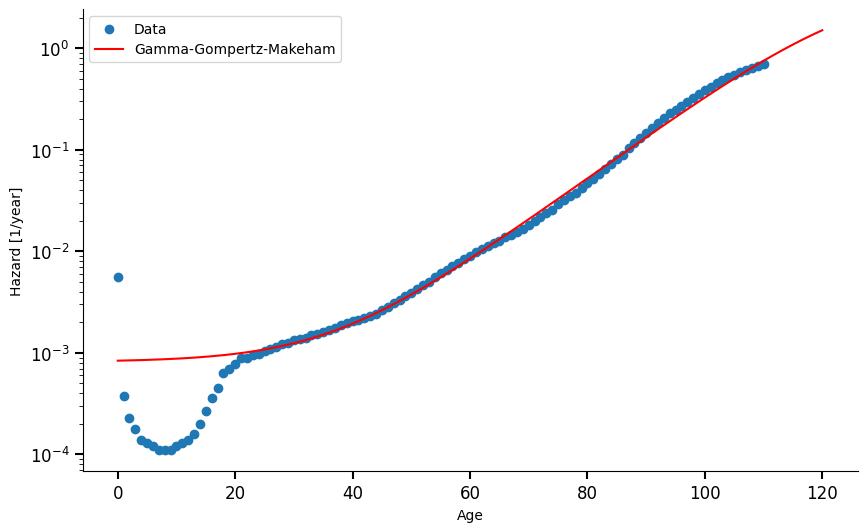

In [13]:
usa = HMD('usa', 'both', 'period')
model = gg()

HMD_params = {
    'country': 'usa',
    'year': 2019,
    'gender': 'both', 
    'data_type': 'period',
    'haz_type': 'mx'
}

model.fit_params(**HMD_params, filter_from=20, filter_to=105)

model.c = 12

model.plot_hazard_with_data_comparison(**HMD_params)

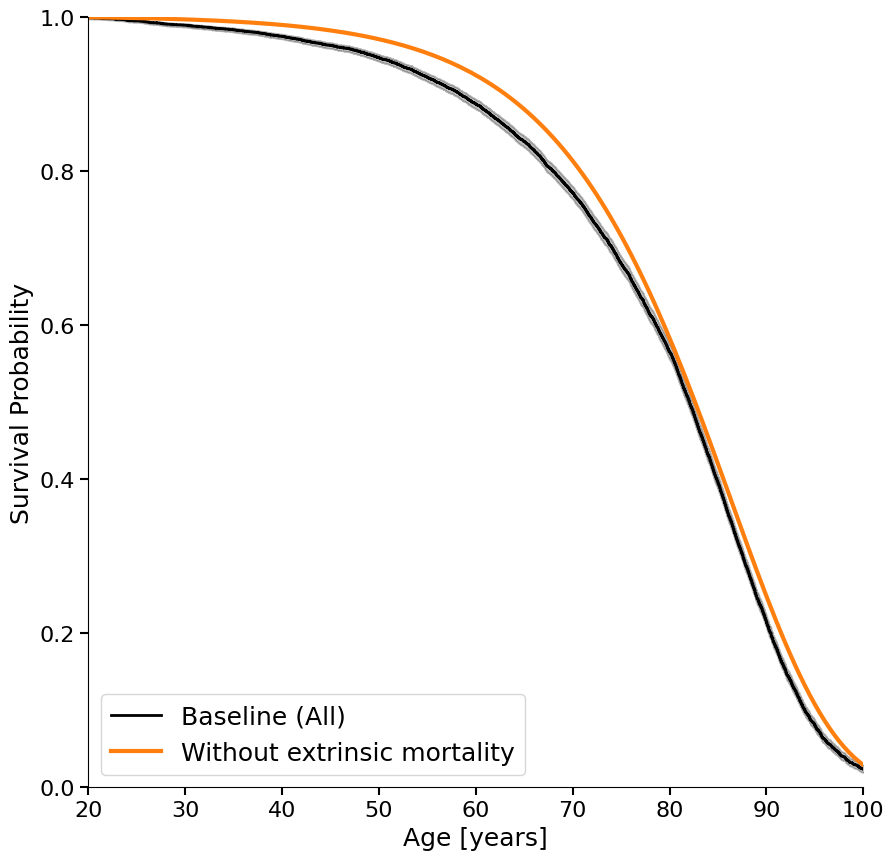

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
plot_baseline_km(ax)
# model.plot_survival_from_age_X(ax = ax, age_X = 20, label = 'Baseline Cohort', linewidth = 3)
model.m = 0
model.plot_survival_from_age_X(ax = ax, age_X = 20, label = 'Without extrinsic mortality', linewidth = 3)
ax.legend(fontsize = 18)
ax.set_xlim(20, 100)
ax.set_ylim(0, 1)
ax.set_xlabel('Age [years]', fontsize = 18)
ax.set_ylabel('Survival Probability', fontsize = 18)
ax.tick_params(labelsize = 16)
ax.grid(False)

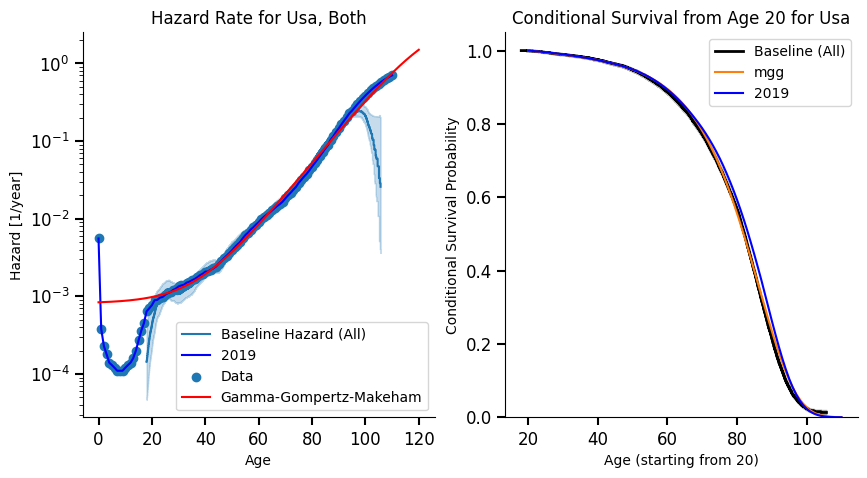

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plot_baseline_hazard(ax1)
usa.plot_hazard(years=2019, ax=ax1)
model.plot_hazard_with_data_comparison(**HMD_params, ax=ax1)
ax1.set_yscale('log')

plot_baseline_km(ax2)
model.plot_survival_from_age_X(ax = ax2,label = 'mgg', age_X = 20)
usa.plot_conditional_survival(age_X=20, ax=ax2, years = 2019)
ax2.legend()


Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl
mgg steepness: 5.26795164103737, usa steepness: 5.238382249820914 , baseline_steepness: 5.318707339260562
mgg steepness / baseline_steepness: 0.9904571364834208
usa steepness / baseline_steepness: 0.98489762938323
mgg steepness / usa steepness: 1.0056447563019035


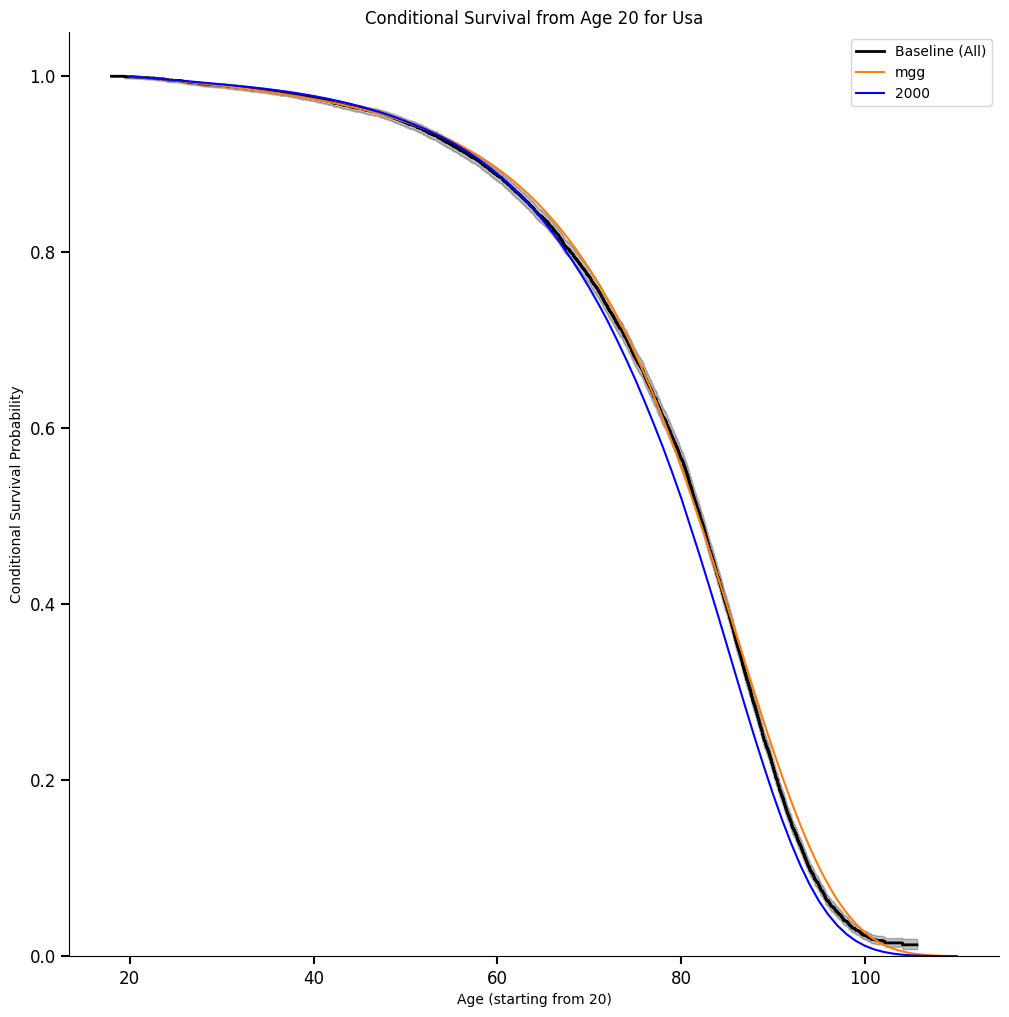

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_baseline_km(ax)
interventions_dict = nhanes.load_interventions_dict()
baseline_steepness = interventions_dict['baseline']['with_extrinsic']['steepness_cv_absolute']

model.plot_survival_from_age_X(ax = ax,label = 'mgg', age_X = 20)
death_times = model.sample_death_times(n=100000, min_age=20)
mu = death_times.mean()
sd = death_times.std()
mgg_steepness = mu / sd


usa.plot_conditional_survival(age_X=20, ax=ax, years = 2000)
death_times_usa = usa.sample_lifespans(year=2019, n_samples=100000, age_start=20)
mu_usa = death_times_usa.mean()
sd_usa = death_times_usa.std()
usa_steepness = mu_usa / sd_usa

print(f'mgg steepness: {mgg_steepness}, usa steepness: {usa_steepness} , baseline_steepness: {baseline_steepness}')
print(f'mgg steepness / baseline_steepness: {mgg_steepness / baseline_steepness}')
print(f'usa steepness / baseline_steepness: {usa_steepness / baseline_steepness}') 
print(f'mgg steepness / usa steepness: {mgg_steepness / usa_steepness}')
ax.legend()


### removing extrinsic mortality

AttributeError: module 'ageing_packages.hetero_analysis.nhanes_analysis' has no attribute 'interventions_dict'

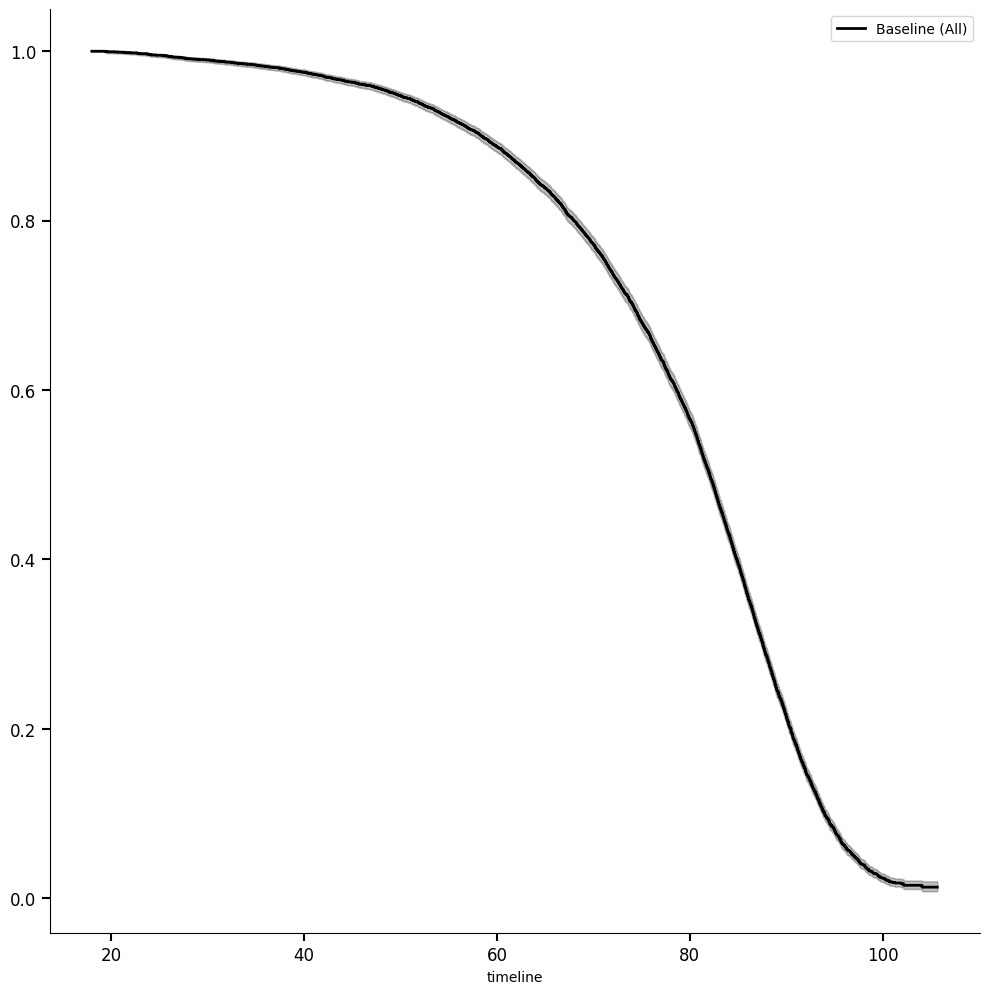

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_baseline_km(ax)
baseline_steepness = nhanes.interventions_dict['baseline']['with_extrinsic']['steepness_cv_absolute']
baseline_median = nhanes.interventions_dict['baseline']['with_extrinsic']['0.50']
usa = HMD('usa', 'both', 'period')
model = gg()

HMD_params = {
    'country': 'usa',
    'year': 2000,
    'gender': 'both', 
    'data_type': 'period',
    'haz_type': 'mx'
}

model.fit_params(**HMD_params, filter_from=20, filter_to=105)
model.m = 0
model.plot_survival_from_age_X(ax = ax,label = 'mgg', age_X = 20)
death_times = model.sample_death_times(n=100000, min_age=20)
mu = death_times.mean()
sd = death_times.std()
mgg_steepness = mu / sd
mgg_median = np.median(death_times)


usa.plot_conditional_survival(age_X=20, ax=ax, years = 2000)
death_times_usa = usa.sample_lifespans(year=2000, n_samples=100000, age_start=20)
mu_usa = death_times_usa.mean()
sd_usa = death_times_usa.std()
usa_steepness = mu_usa / sd_usa
usa_median = np.median(death_times_usa)

print(f'mgg median: {mgg_median}, usa median: {usa_median} , baseline_median: {baseline_median}')
print(f'mgg median / baseline_median: {mgg_median / baseline_median}')
print(f'usa median / baseline_median: {usa_median / baseline_median}') 
print(f'mgg median / usa median: {mgg_median / usa_median}')

print(f'mgg steepness: {mgg_steepness}, usa steepness: {usa_steepness} , baseline_steepness: {baseline_steepness}')
print(f'mgg steepness / baseline_steepness: {mgg_steepness / baseline_steepness}')
print(f'usa steepness / baseline_steepness: {usa_steepness / baseline_steepness}') 
print(f'mgg steepness / usa steepness: {mgg_steepness / usa_steepness}')
ax.legend()




checking

# Full df

In [7]:
df = nhanes.create_full_df()

print(f"Length of df: {len(df)}")
print(f"Number of rows with all columns not null: {df.notna().all(axis=1).sum()}")
print(f"Are all SEQN unique? {df['SEQN'].is_unique}")
print(f"Maximum SEQN: {df['SEQN'].max()}")
print(f"Minimum SEQN: {df['SEQN'].min()}")
print("\nNumber of rows with values for each column:")
for col in df.columns:
    print(f"{col}: {df[col].notna().sum()}")

Length of df: 59064
Number of rows with all columns not null: 887
Are all SEQN unique? True
Maximum SEQN: 102956
Minimum SEQN: 2

Number of rows with values for each column:
SEQN: 59064
entry_age: 59064
exit_age: 59064
dead: 59064
diet_quality: 41996
income_ratio: 31234
alcohol_drinks_per_day: 31852
physical_activity_index: 36461
sleep_duration_hours: 41925
sleep_frailty_index: 11780
work_schedule: 9990
need_for_support: 12738
number_of_friends: 13668
church_frequency: 7052
education_level: 54827


In [8]:
df[df.notna().all(axis=1)].head()

,SEQN,entry_age,exit_age,dead,diet_quality,income_ratio,alcohol_drinks_per_day,physical_activity_index,sleep_duration_hours,sleep_frailty_index,work_schedule,need_for_support,number_of_friends,church_frequency,education_level
22605,41479,52.416667,64.416667,0,2,1.69,5,0.791889,6,0.242843,Rotating shift,0,3,24,no highschool
22607,41482,64.833333,76.166667,0,2,1.90,4,0.536035,8,0.250197,Daytime work,0,8,0,no highschool
22612,41489,40.166667,52.083333,0,3,2.45,5,0.000000,6,0.332349,Daytime work,0,10,52,high school
22616,41494,40.000000,51.666667,0,2,1.09,5,0.919867,5,0.310941,Rotating shift,0,2,48,high school
22617,41495,61.583333,74.000000,0,2,5.00,2,0.625158,7,0.592593,Night shift,1,0,0,some college


# Fitting SR params to baseline

In [41]:
usa = HMD('usa', 'both', 'period')
model = gg()

HMD_params = {
    'country': 'usa',
    'year': 2019,
    'gender': 'both', 
    'data_type': 'period',
    'haz_type': 'mx'
}

model.fit_params(**HMD_params, filter_from=20, filter_to=105)

model.c = 12



a:  2.433748404546741e-05
b:  0.09586888375577891
c:  46.595725953296366
m:  0.0008133635731385147


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


### mgg model for usa 2019 fits really well baseline nhanes 

/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_models/gamma_gompertz.py:535: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


<lifelines.KaplanMeierFitter:"Baseline (All)", fitted with 59064 total observations, 49815 right-censored observations>

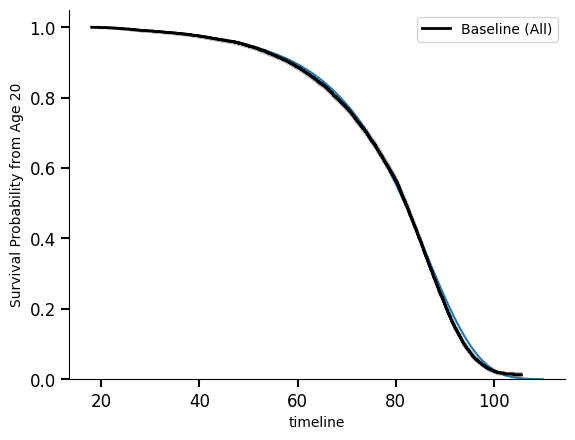

In [42]:
fig, ax = plt.subplots()
model.plot_survival_from_age_X(ax=ax, age_X = 20)
plot_baseline_km(ax=ax)

In [57]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 0.97*dict['Xc']
dict['epsilon'] = 1.05*dict['epsilon']
dict['eta'] = 0.96*dict['eta']
print(dict['Xc'])
sr_sim = utils.create_sr_simulation(n = 10000, parallel = False, params_dict = dict)
plotter = SR_plotting(sr_sim)

[16.49]


/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_models/gamma_gompertz.py:535: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


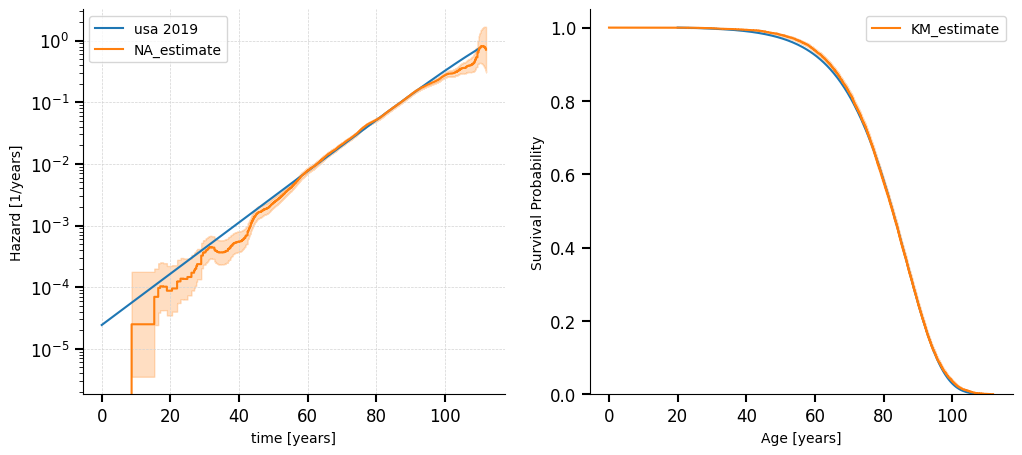

In [59]:
model.m = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - hazard
model.plot_hazard(ax=ax1, label='usa 2019')
plotter.plot_hazard(ax=ax1)

# Right plot - survival
model.plot_survival_from_age_X(ax=ax2, age_X=20)
plotter.plot_survival_from_age_X(ax=ax2, age_X = 20)


/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_models/gamma_gompertz.py:535: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


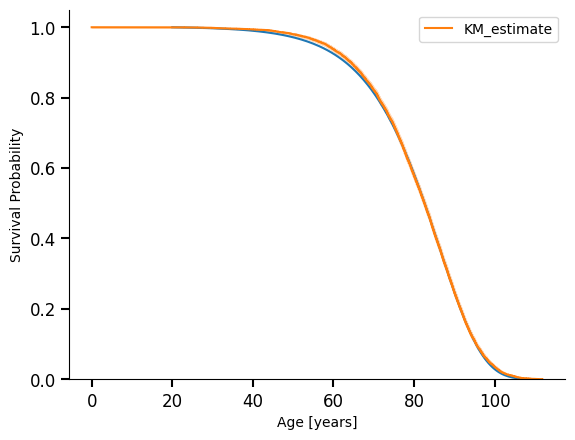

In [58]:
fig, ax = plt.subplots()
# Right plot - survival
model.plot_survival_from_age_X(ax=ax, age_X=20)
plotter.plot_survival_from_age_X(ax=ax, age_X = 20)


### lets try adding hetero to Xc and fitting

In [31]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 1.25*dict['Xc']
dict['epsilon'] = 1*dict['epsilon']
dict['eta'] = dict['eta']
dict['beta'] = 0.97*dict['beta']
dict['eta'] = 1.1*dict['eta']
dict = utils.create_param_distribution_dict(params_dict = dict, params = 'Xc' , std = 0.2, n = 10000)

sr_sim = utils.create_sr_simulation(n = 10000, parallel = False, params_dict = dict)
plotter = SR_plotting(sr_sim)

In [46]:
sr_sim.params.print_params()

η = 0.00148 day⁻¹·year⁻¹, β = 0.15 day⁻¹, κ = 0.5, ε = 51.830 day⁻¹, Xc = 21


/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_models/gamma_gompertz.py:535: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


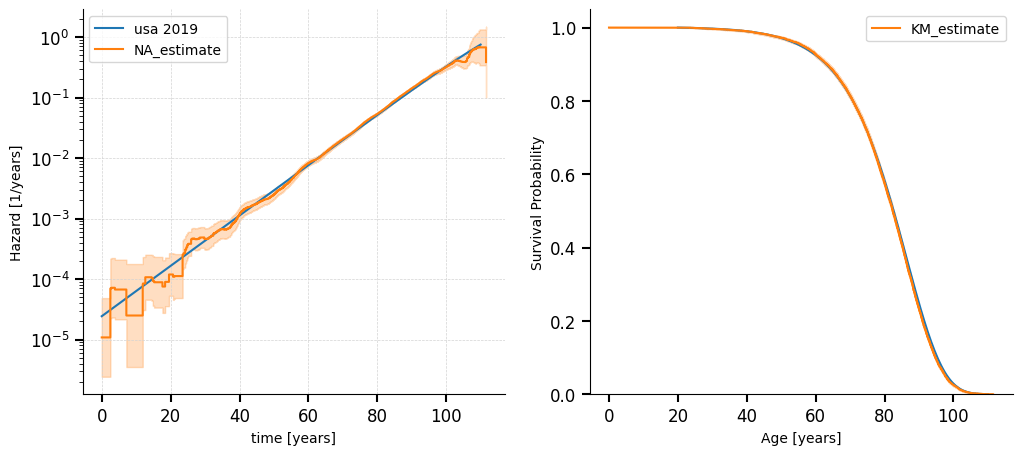

In [ ]:
model.m = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - hazard
model.plot_hazard(ax=ax1, label='usa 2019')
plotter.plot_hazard(ax=ax1)

# Right plot - survival
model.plot_survival_from_age_X(ax=ax2, age_X=20)
plotter.plot_survival_from_age_X(ax=ax2, age_X = 20)


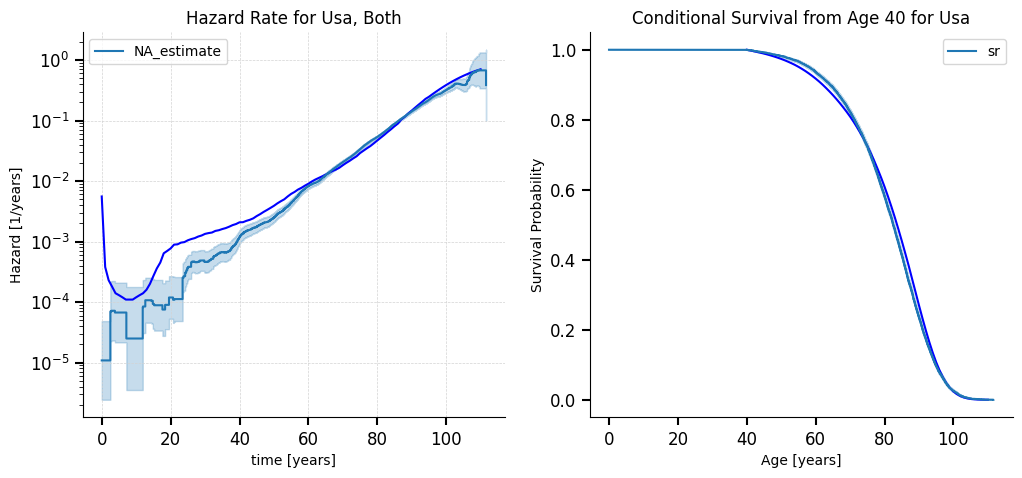

In [44]:
model.m = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - hazard
usa.plot_hazard(ax=ax1, years = 2019)
plotter.plot_hazard(ax=ax1)

# Right plot - survival
usa.plot_conditional_survival(age_X = 40, ax = ax2, years = 2019)
plotter.plot_survival_from_age_X(ax=ax2, age_X = 40, label = 'sr')


### creating studies

In [34]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 1.25*dict['Xc']
dict['beta'] = 0.97*dict['beta']
dict['eta'] = 1.1*dict['eta']
n=3e5
dict = utils.create_param_distribution_dict(params_dict = dict, params = 'Xc' , std = 0.2, n = n)

th.run_parameter_study(study_type = 'variation' , name = 'usa_2019_with_hetero', baseline_dict = dict)

Processing parameter: eta
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
  Factor: 1.60 completed
  Factor: 1.70 completed
Processing parameter: beta
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
  Factor: 1.60 completed
  Factor: 1.70 completed
Processing parameter: epsilon
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 co

{'baseline': {0: {'steepness_iqr_relative': 5.1487273409765155,
   'steepness_iqr_absolute': 5.1487273409765155,
   'steepness_cv_relative': 6.0283651564047185,
   'steepness_cv_absolute': 6.0283651564047185,
   't_median_relative': 82.2924528301887,
   't_median_absolute': 82.2924528301887,
   't_max': 110.8125},
  15: {'steepness_iqr_relative': 4.223551836750292,
   'steepness_iqr_absolute': 5.164676119517054,
   'steepness_cv_relative': 5.038000228401038,
   'steepness_cv_absolute': 6.193497379837507,
   't_median_relative': 67.31659007352941,
   't_median_absolute': 82.31659007352941,
   't_max': 110.81315125},
  20: {'steepness_iqr_relative': 3.9155446940083,
   'steepness_iqr_absolute': 5.171982021842842,
   'steepness_cv_relative': 4.699055820775121,
   'steepness_cv_absolute': 6.253726264748984,
   't_median_relative': 62.3277358490566,
   't_median_absolute': 82.32773584905661,
   't_max': 110.81345250000001},
  30: {'steepness_iqr_relative': 3.3068235327138935,
   'steepness_

(0.5, 1.5)

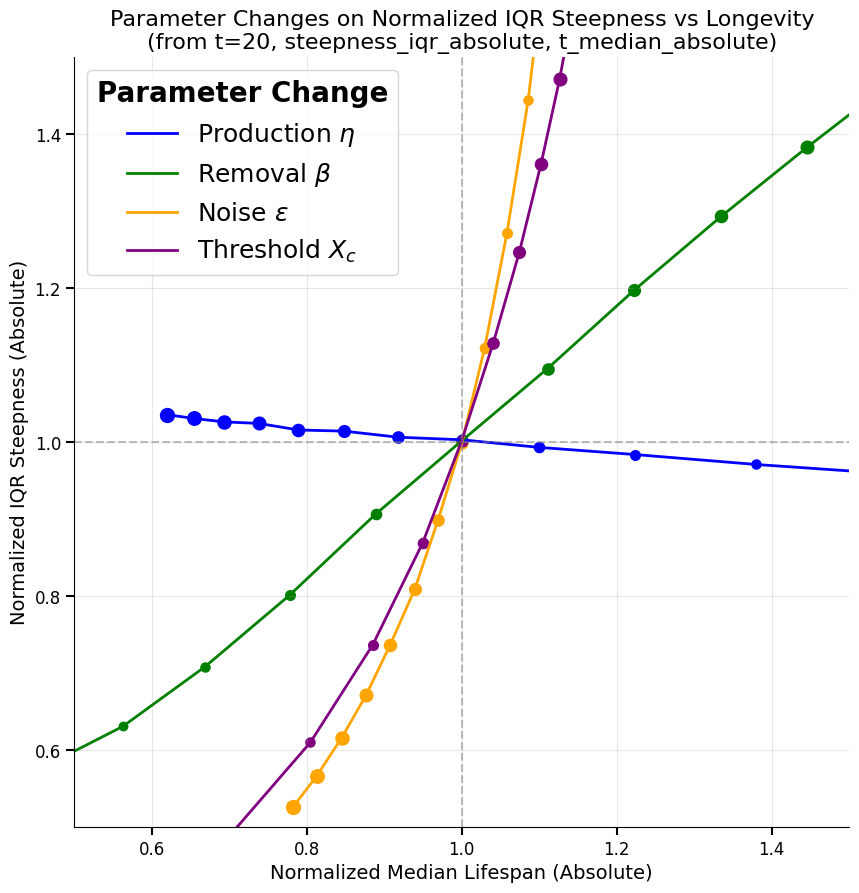

In [39]:
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
th.plot_steepness_longevity(pkl_file = 'param_variation_results_usa_2019_with_hetero.pkl', from_t = 20, ax = ax)
ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 1.5)

In [ ]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 0.97*dict['Xc']
dict['epsilon'] = 1.05*dict['epsilon']
dict['eta'] = 0.96*dict['eta']

th.run_parameter_study(study_type = 'variation' , name = 'usa_2019', baseline_dict = dict)